# Segmentation: Energy Minimization with Conditional Random Fields

Rohan Koshy

ECE 278A — Digital Image Processing — Spring 2026  
05/12/2026


In [1]:
# Import Cell

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, filters
from skimage.transform import resize
from sklearn.mixture import GaussianMixture

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)



# The Segmentation Problem (Bayesian view)

Given an observed image $y$ (pixel values from the camera), we want to assign every pixel a label $x_i \in \mathcal{L}$ — foreground vs. background, or one of $K$ classes.

The natural question: **which labeling is most probable, given the image we observed?**

$$
\hat{x} \;=\; \arg\max_x \; p(x \mid y)
$$

This is called **Maximum A Posteriori (MAP) inference** — find the labeling that maximizes the posterior probability $p(x \mid y)$.


# From Posterior to Energy

Bayes' rule:

$$
p(x \mid y) \;=\; \frac{p(y \mid x) \cdot p(x)}{p(y)}
$$

- **Likelihood** $p(y \mid x)$: if the true labels were $x$, how likely is the image $y$ we observed?
- **Prior** $p(x)$: before looking at any image, which labelings are plausible in general?
- **Evidence** $p(y)$: a constant that doesn't depend on $x$

Take the negative log of both sides (monotonic, converts product into sum):

$$
-\log p(x \mid y) \;=\; \underbrace{-\log p(y \mid x)}_{E_D(x, y)} \;+\; \underbrace{-\log p(x)}_{E_P(x)} \;+\; \text{const}
$$

**Maximizing posterior probability = minimizing this energy.** MAP inference *is* energy minimization.


# The Energy Function

Define:

$$
E(x, y) \;=\; \underbrace{-\log p(y \mid x)}_{\text{data term } E_D} \;+\; \underbrace{-\log p(x)}_{\text{prior term } E_P}
$$

To make this concrete, we assume that:

**1.** *Pixels are conditionally independent given their labels:* $p(y \mid x) = \prod_i p(y_i \mid x_i)$

$$
E_D(x, y) \;=\; \sum_i \underbrace{-\log p(y_i \mid x_i)}_{D_i(x_i)}
$$




# The Markov Random Field



We need a prior $p(x)$ over labelings. 

To represent the priors, the Markov property is applied:
**The Markov property on a graph.** Each pixel's label depends only on its immediate neighbors, not on every other pixel in the image:

$$
P(x_i \mid x_{\setminus i}) \;=\; P(x_i \mid x_{\mathcal{N}(i)})
$$

This is a simplifying assumption that most label structure in images can be localized. 

A distribution satisfying this property is called a **Markov Random Field (MRF)** on the pixel graph.

**Hammersley–Clifford theorem:** any positive distribution that's Markov on graph $G$ factors over the graph's cliques as

$$
p(x) \;=\; \frac{1}{Z}\, \exp\!\Bigl(-\sum_c \psi_c(x_c)\Bigr)
$$

For our 4-connected pixel graph, the cliques are nodes and edges — so the energy decomposes into **unary** and **pairwise** terms.

Putting it together:

$$
\boxed{\,E(x, y) \;=\; \sum_i D_i(x_i) \;+\; \sum_{(i,j)} V_{i,j}(x_i, x_j)\,}
$$


# Choosing the Unary Term $D_i$

$D_i(x_i) = -\log p(y_i \mid x_i)$ — different choices of likelihood model give different cost fields.

- **GMM on scribbles** *(GrabCut)*: fit a Gaussian Mixture to user-labeled foreground/background pixels.  
  $D_i(l) = -\log p_\text{GMM}(\text{color}_i \mid l)$
- **Intensity threshold** *(simplest)*: $D_i(l)$ small when pixel intensity matches expected range for label $l$.
- **Color-distance** *(seed-based)*: $D_i(l) \propto \|\text{color}_i - \mu_l\|^2$ where $\mu_l$ is the mean color of seed pixels labeled $l$.
- **Learned classifier** *(modern)*: $D_i(l) = -\log p_\text{classifier}(l \mid \text{patch}_i)$, e.g., CNN logits.

*Each choice is a different model of how labels generate pixel values. Let's see what they look like.*


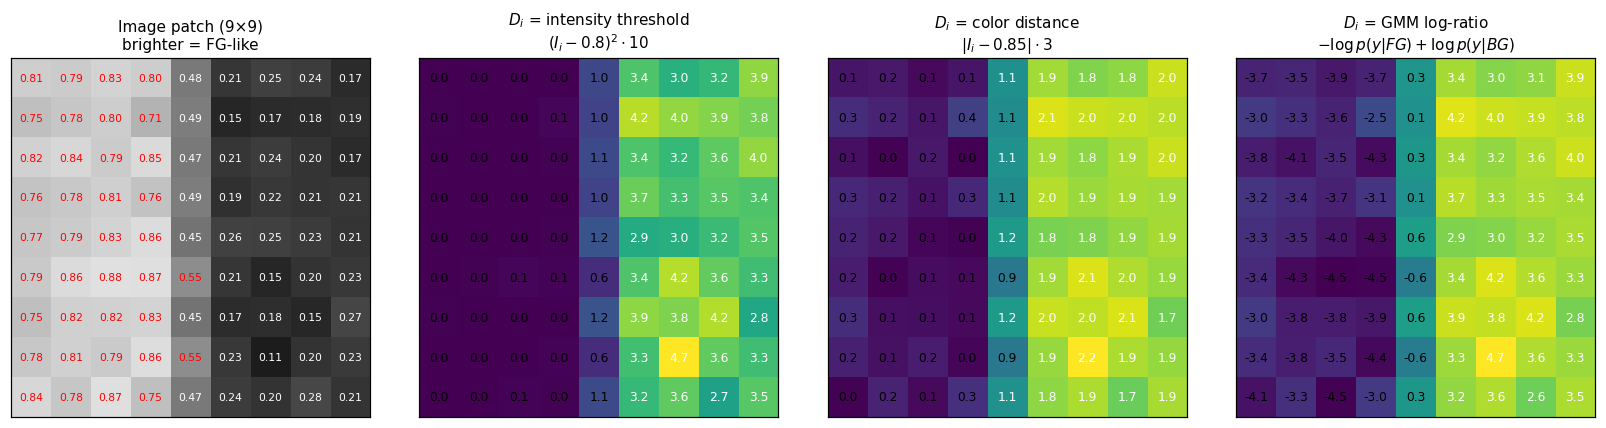

In [2]:
# What does D_i actually look like? Take a small 9x9 patch and show the
# numerical cost values directly, side by side for three different D_i choices.
# This makes 'D_i is a number per pixel' completely concrete.

# Synthetic 9x9 patch: bright pixels on the left (FG-like), dark on the right (BG-like),
# with a narrow ambiguous boundary column.
rng = np.random.default_rng(0)
patch = np.zeros((9, 9))
patch[:, :4] = 0.8
patch[:, 5:] = 0.2
patch[:, 4] = 0.5
patch += 0.04 * rng.normal(size=patch.shape)
patch = np.clip(patch, 0, 1)

# Three different D_i(foreground) cost choices:
D_intensity = (patch - 0.8) ** 2 * 10                 # quadratic around FG color
D_distance = np.abs(patch - 0.85) * 3                 # linear distance
sigma_sq = 0.05                                        # GMM-style log-ratio
D_gmm = -0.5 * (patch - 0.8)**2 / sigma_sq + 0.5 * (patch - 0.2)**2 / sigma_sq
D_gmm = -D_gmm  # so larger = more BG-like (higher cost to label FG)


def draw_grid(ax, values, title, cmap="viridis", fmt="{:.1f}", with_image=False, image=None):
    """Draw a small grid with numerical values overlaid."""
    ax.imshow(values, cmap=cmap)
    h, w = values.shape
    vmax = values.max()
    for i in range(h):
        for j in range(w):
            val = values[i, j]
            text_color = "white" if val > vmax * 0.5 else "black"
            ax.text(j, i, fmt.format(val), ha="center", va="center",
                    fontsize=8, color=text_color)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

# Image patch with intensity values
axes[0].imshow(patch, cmap="gray", vmin=0, vmax=1)
for i in range(9):
    for j in range(9):
        c = "red" if patch[i, j] > 0.5 else "white"
        axes[0].text(j, i, f"{patch[i,j]:.2f}", ha="center", va="center", fontsize=7, color=c)
axes[0].set_title("Image patch (9×9)\nbrighter = FG-like", fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])

draw_grid(axes[1], D_intensity, "$D_i$ = intensity threshold\n$(I_i - 0.8)^2 \\cdot 10$")
draw_grid(axes[2], D_distance,  "$D_i$ = color distance\n$|I_i - 0.85| \\cdot 3$")
draw_grid(axes[3], D_gmm,       "$D_i$ = GMM log-ratio\n$-\\log p(y|FG) + \\log p(y|BG)$")

plt.tight_layout(); plt.show()

# Every cell in each D_i panel shows the actual cost of labeling that pixel foreground.
# Low cost (dark purple) = the model thinks this pixel is likely FG.
# High cost (yellow) = the model thinks this pixel is unlikely FG.
# Three different functional choices — all agree that left side is FG, right side is BG,
# but the cost magnitudes and sensitivities differ.


# Choosing the Pairwise Term $V_{i,j}$

$V_{i,j}(x_i, x_j)$ encodes the prior: how neighboring labels should relate to each other, independent of what we observe.

**The Potts model** is the popular choice for MRFs:

$$
V_{i,j}(x_i, x_j) \;=\; w \cdot \mathbf{1}[x_i \ne x_j]
$$

Pay a constant cost $w$ whenever neighbors take different labels; pay zero when they agree. It encodes the assumption that neighboring pixels usually will have similar classifications. 


# The MRF as a Graphical Model

<center><img src="markov_random_field_diagram.png" width="500"></center>

Each pixel position in the image has three associated objects:

- **White circles** $f(i, j)$ — the **unknown labels** we want to estimate. In our notation, $x_i$.
- **Gray circles** $d(i, j)$ — the **observed pixel values** from the camera. In our notation, $y_i$.

**The cost functions:**

- $c(i, j)$ — the **unary cost / data term**. Connects label $f(i, j)$ to its observation $d(i, j)$. Returns the cost of assigning this label given this pixel value. This is $D_i(x_i)$. 
- $s_x(i, j)$ — the **horizontal pairwise / smoothness term**. Connects $f(i, j)$ to its right neighbor $f(i+1, j)$. Returns the cost of this label pair. This is $V_{i, i+1}$.
- $s_y(i, j)$ — the **vertical pairwise term**. Same idea, between $f(i, j)$ and $f(i, j+1)$.

**Blue edges:** the extra diagonal factors that appear if we use an **8-connected** neighborhood instead of 4-connected. They add pairwise costs between diagonally adjacent labels.

**The key observation:** every square box becomes one term in the energy.

$$
E(x, y) \;=\; \underbrace{\sum_i c(i,j)\,(f(i,j), d(i,j))}_{\text{one unary per pixel}} \;+\; \underbrace{\sum_{(i,j)} s_x + s_y}_{\text{one pairwise per edge}}
$$

*The graph structure **is** the energy structure. Hammersley-Clifford guarantees this: an MRF on this graph must factor into exactly these per-clique terms.*

---
# Optimizers

Now once we have a energy function representing the image, we must find a way to solve the minimization.


**The brute-force problem.** A labeling assigns one of $K$ labels to each of $N$ pixels. The number of possible labelings is:

$$
K^N
$$

For a 500×500 binary segmentation: $2^{250{,}000}$, much too large to exhaustively search.


This is why there are several different optimizers used to find one of the best solutions to energy minimize. They do not guarantee the lowest energy solution.


# What the Optimizers are Doing

All four methods below minimize the **same energy** on the cameraman image, with Otsu's threshold as the initial observation classification:

$$
E(f) \;=\; \underbrace{w \sum_i \delta\bigl(f(i), d(i)\bigr)}_{\text{data term}} \;+\; \underbrace{s \sum_{(i,j) \in \mathcal{N}} \delta\bigl(f(i), f(j)\bigr)}_{\text{Potts smoothness}}
$$

They differ only in *how* they minimize it.

| Optimizer | What it does | Behavior |
|---|---|---|
| **ICM** | Visit each pixel, flip if it lowers energy locally | Fast but greedy — gets stuck |
| **Simulated annealing** | Like ICM, but accept uphill moves with decreasing probability | Escapes local minima, but slow |
| **Graph cuts** | Reformulate as min-cut on a flow graph | **Exact global minimum** for binary submodular energies |
| **Loopy belief propagation** | Pass messages along edges between neighbors | Different paradigm — works for arbitrary pairwise costs |



# ICM — Iterated Conditional Modes

**The simplest possible optimizer.**

Loop over every pixel. For each pixel, look at its current neighbors. Pick whichever label minimizes the local energy at that pixel. Move on. Repeat for several passes until labels stop changing.

It's greedy coordinate descent on the energy. Each step only ever considers single-pixel flips — so once the algorithm reaches a configuration where flipping any single pixel would *increase* energy, it stops, even if a coordinated multi-pixel change would have done better.


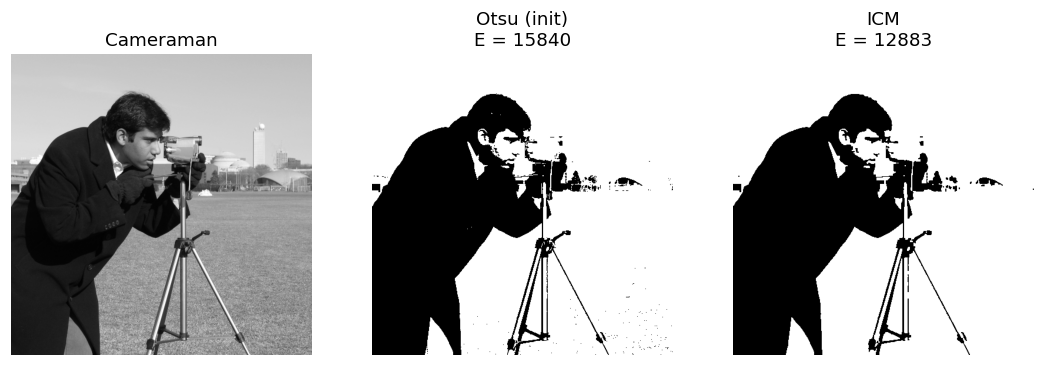

In [3]:
# === Block 1: Otsu thresholding + ICM ===
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters

# Shared setup: cameraman + Otsu binarization + Potts energy
gray = data.camera() / 255.0
d = (gray > filters.threshold_otsu(gray)).astype(int)
H, W = d.shape
W_DATA, S_SMOOTH = 1.0, 2.0

def energy(f):
    U = W_DATA * (f != d).sum()
    P = S_SMOOTH * ((f[:,:-1] != f[:,1:]).sum() + (f[:-1,:] != f[1:,:]).sum())
    return U + P

# ICM: flip each pixel to its lower-energy label, repeat
def icm(n_iters=5):
    f = d.copy()
    for _ in range(n_iters):
        for i in range(H):
            for j in range(W):
                nbrs = [f[i+di,j+dj] for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]
                        if 0<=i+di<H and 0<=j+dj<W]
                e0 = W_DATA*(0!=d[i,j]) + S_SMOOTH*sum(n!=0 for n in nbrs)
                e1 = W_DATA*(1!=d[i,j]) + S_SMOOTH*sum(n!=1 for n in nbrs)
                f[i,j] = 0 if e0 < e1 else 1
    return f

f_icm = icm()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
panels = [('Cameraman', gray), ('Otsu (init)', d), ('ICM', f_icm)]
for a, (t, im) in zip(ax, panels):
    a.imshow(im, cmap='gray')
    title = t if t == 'Cameraman' else f'{t}\nE = {energy(im):.0f}'
    a.set_title(title); a.axis('off')
plt.show()

# Simulated Annealing

**ICM gets stuck because every move is downhill. What if we allow uphill moves sometimes?**

Same loop as ICM, but at each pixel:

- If flipping the label *decreases* energy → always accept
- If flipping *increases* energy by $\Delta E$ → accept with probability $\exp(-\Delta E / T)$

The temperature $T$ starts high (most uphill moves accepted, basically a random walk) and slowly decreases (becomes increasingly greedy, converges to ICM in the limit).

The randomness lets it climb out of shallow local minima and find a deeper one. *Theoretically* with a slow enough cooling schedule it reaches the global optimum — practically it just does noticeably better than ICM.


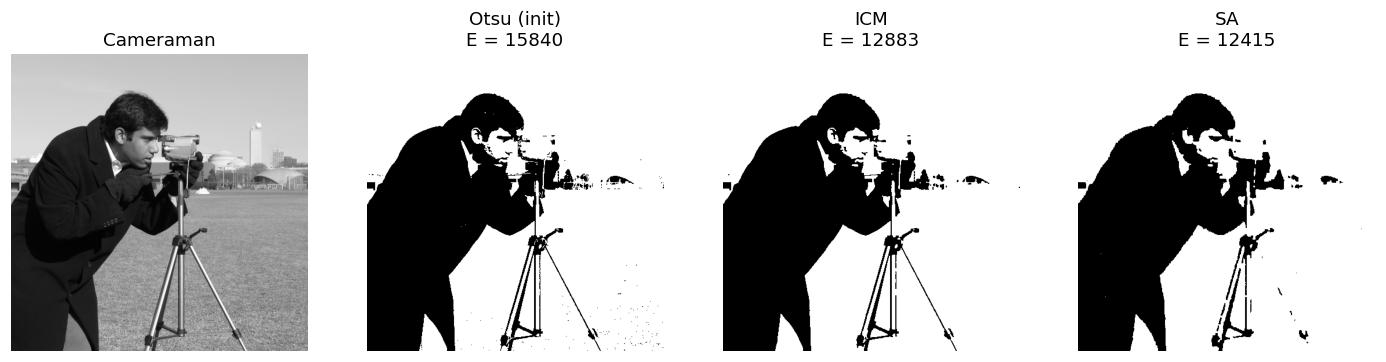

In [4]:
# === Block 2: + Simulated annealing ===
def sa(n_iters=5, T0=2.0):
    f, T = d.copy(), T0
    rng = np.random.default_rng(0)
    for _ in range(n_iters):
        for i in range(H):
            for j in range(W):
                nbrs = [f[i+di,j+dj] for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]
                        if 0<=i+di<H and 0<=j+dj<W]
                cur = f[i,j]; alt = 1 - cur
                dE = (W_DATA*(alt!=d[i,j]) + S_SMOOTH*sum(n!=alt for n in nbrs)
                    - W_DATA*(cur!=d[i,j]) - S_SMOOTH*sum(n!=cur for n in nbrs))
                if dE < 0 or rng.random() < np.exp(-dE/T):
                    f[i,j] = alt
        T *= 0.8
    return f

f_sa = sa()

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
panels = [('Cameraman', gray), ('Otsu (init)', d), ('ICM', f_icm), ('SA', f_sa)]
for a, (t, im) in zip(ax, panels):
    a.imshow(im, cmap='gray')
    title = t if t == 'Cameraman' else f'{t}\nE = {energy(im):.0f}'
    a.set_title(title); a.axis('off')
plt.show()

# Graph Cuts

**Instead of moving label-by-label, reformulate the whole problem as a flow on a graph.**

Build a graph where:
- Each pixel is a node
- A **source** node represents "foreground", a **sink** node represents "background"
- Each pixel is connected to source/sink with capacities derived from the **unary** term
- Neighboring pixels are connected to each other with capacities equal to the **pairwise** cost

A **min-cut** on this graph separates pixels into two sets (source-side = FG, sink-side = BG). The *cost* of the cut exactly equals the energy of the resulting labeling.

So minimizing energy = finding min-cut = (by duality) computing max-flow. Polynomial time, **exact global optimum** — for any binary problem where the pairwise term is submodular (Potts is).


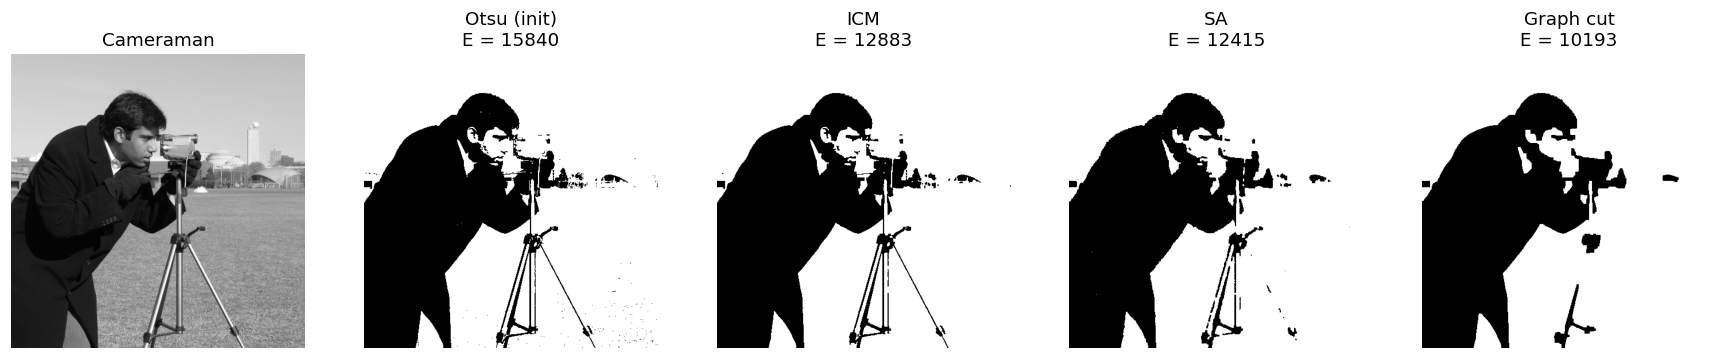

In [5]:
# === Block 3: + Graph cut ===
import maxflow

def graph_cut():
    g = maxflow.Graph[float]()
    nodes = g.add_grid_nodes((H, W))
    g.add_grid_tedges(nodes, W_DATA*(d!=1), W_DATA*(d!=0))
    g.add_grid_edges(nodes, S_SMOOTH)
    g.maxflow()
    return (g.get_grid_segments(nodes)).astype(int)

f_gc = graph_cut()

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
panels = [('Cameraman', gray), ('Otsu (init)', d),
          ('ICM', f_icm), ('SA', f_sa), ('Graph cut', f_gc)]
for a, (t, im) in zip(ax, panels):
    a.imshow(im, cmap='gray')
    title = t if t == 'Cameraman' else f'{t}\nE = {energy(im):.0f}'
    a.set_title(title); a.axis('off')
plt.show()

# Loopy Belief Propagation

**Different paradigm: instead of flipping pixels or finding cuts, pass messages along graph edges.**

Each pixel sends each neighbor a *message* — a vector of "beliefs" about what label that neighbor should take. Each message accounts for the sender's own unary cost and the messages it's received from its *other* neighbors. After enough iterations, beliefs stabilize and each pixel picks the label with the lowest belief.

On a tree, this gives the exact global optimum. On a graph with cycles ("loopy"), it's only approximate — but it's a totally different mechanism from graph cuts, and it works for energies graph cuts can't handle (non-submodular pairwise, non-metric label distances).

**Why it's worth knowing:** graph cuts dominate binary segmentation, but the dense CRF inference we'll see in Block 4 (mean-field) is conceptually part of this *message-passing* family, not the graph-cut family.


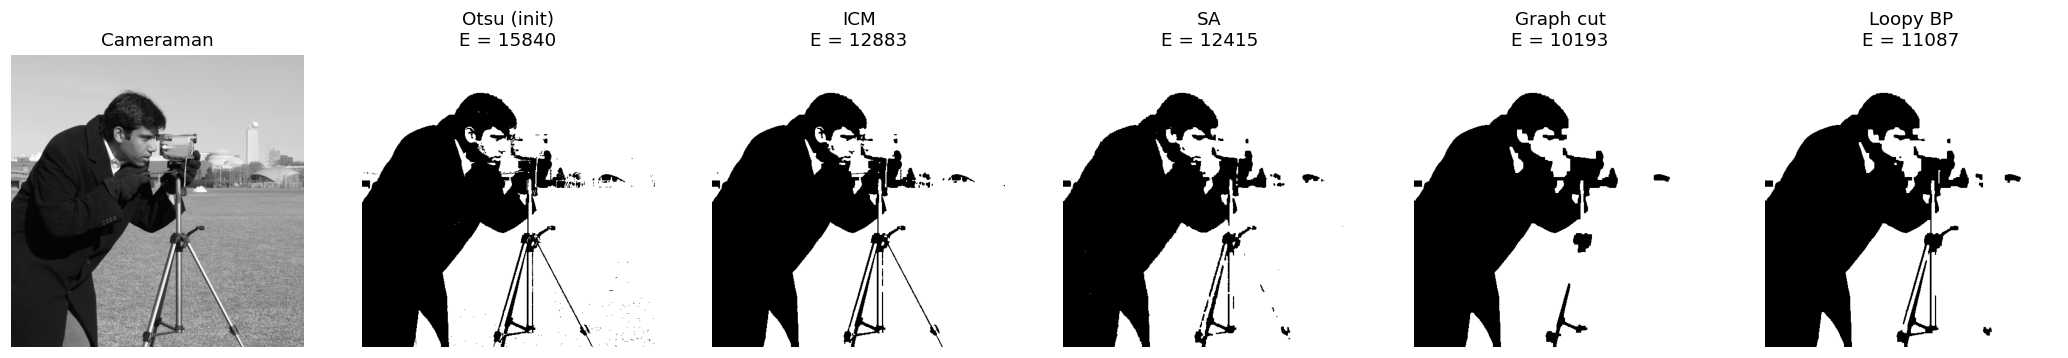

In [6]:
# === Block 4: + Loopy BP ===
def loopy_bp(n_iters=10):
    phi = np.stack([W_DATA*(d!=0), W_DATA*(d!=1)], axis=-1)
    psi = S_SMOOTH * np.array([[0,1],[1,0]])
    m = {k: np.zeros((H,W,2)) for k in 'NSEW'}

    def gather(exclude):
        out = np.zeros((H,W,2))
        if exclude != 'N': out[1:]    += m['S'][:-1]
        if exclude != 'S': out[:-1]   += m['N'][1:]
        if exclude != 'W': out[:,1:]  += m['E'][:,:-1]
        if exclude != 'E': out[:,:-1] += m['W'][:,1:]
        return out

    for _ in range(n_iters):
        new = {}
        for k in 'NSEW':
            total = phi + gather(k)
            msg = np.stack([np.minimum(total[...,0]+psi[0,0], total[...,1]+psi[1,0]),
                            np.minimum(total[...,0]+psi[0,1], total[...,1]+psi[1,1])], axis=-1)
            new[k] = msg - msg.min(-1, keepdims=True)
        m = new
    return (phi + gather(None)).argmin(-1)

f_bp = loopy_bp()

fig, ax = plt.subplots(1, 6, figsize=(24, 4))
panels = [('Cameraman', gray), ('Otsu (init)', d), ('ICM', f_icm),
          ('SA', f_sa), ('Graph cut', f_gc), ('Loopy BP', f_bp)]
for a, (t, im) in zip(ax, panels):
    a.imshow(im, cmap='gray')
    title = t if t == 'Cameraman' else f'{t}\nE = {energy(im):.0f}'
    a.set_title(title); a.axis('off')
plt.show()

# Takeaway

All four optimizers minimize the **same energy** on the **same image**. Their relative performance is:

$$
E_\text{init (Otsu)} \;>\; E_\text{ICM} \;>\; E_\text{SA} \;>\; E_\text{LBP} \;\geq\; E_\text{Graph cut (exact)}
$$

- **ICM** is fast and easy but greedy — gets trapped at the first local minimum.
- **Simulated annealing** does better by adding randomness, at the cost of speed.
- **Graph cuts** find the *exact* global minimum for our binary submodular problem — the strongest result, when applicable.
- **Loopy BP** gets close to the global minimum via a totally different mechanism (message passing) — useful when graph cuts don't apply.

## Research Paper: Enhancing Brain Segmentation in MRI through Integration of Hidden Markov Random Field Model and Whale Optimization Algorithm

Daoudi & Mahmoudi (2024) segmenting brain MRI scans into the three main types of tissues: (white matter, gray matter, and cerebrospinal fluid) The issue is that brain tissues have overlapping intensity ranges in MRI, scans contain noise, and tissue boundaries are convoluted.

Their proposed method, **HMRF-WOA**, combines two pieces:
- A **Hidden Markov Random Field (HMRF)** to model the segmentation probabilistically.
- A **Whale Optimization Algorithm (WOA)** —an optimization model for solving the MRF.

They evaluate on BrainWeb (simulated MRIs at various noise/INU levels) and the IBSR (real T1-weighted scans).

Daoudi, A.; Mahmoudi, S. Enhancing Brain Segmentation in MRI through Integration of Hidden Markov Random Field Model and Whale Optimization Algorithm. Computers 2024, 13, 124. https://doi.org/10.3390/computers13050124

# The MRF used


The label prior P(X) uses a Potts model on an 8-neighborhood. For each pair of neighboring pixels (i, j), the clique potential is:

$$U_c(x_i, x_j) = \beta \cdot (1 - V(x_i, x_j))$$

where V equals 1 if the two neighbors share a label and 0 otherwise. The weight β is a constant (they fix β = 1), which means it does not depend on image features.  

**The likelihood P(Y | X)** assumes conditional independence of pixel intensities given their labels, with each class generating intensities from a Gaussian distribution N(μ_xs, σ²_xs). This is the classical "each pixel's appearance depends only on its own class" assumption.

**Unary Term** A data classifier term: the negative log-likelihood under the Gaussian emission model.

**HMRF** The true labels of the pixels are hidden to the optimizer, so they must estimate it. The point is for image classification to be more based on priors.




## Conditional Random Fields Introduction



# The Issues with MRF (Bayesian Approach)

The Potts prior says one thing: **neighboring pixels should share a label**. Every disagreement costs $w$, everywhere, the same:

$$
V_{i,j}(x_i, x_j) \;=\; w \cdot \mathbf{1}[x_i \ne x_j]
$$

The penalty does not depend on $y$. It cannot — under a generative MRF, the prior $p(x)$ is by construction independent of the observation. The smoothing is **blind to the image**.

This means

- **Thin structures get erased.** Tripod legs, power lines, hair, antennae. Narrow enough that smoothing a few pixels inward eats the whole thing. Potts sees a small region surrounded by disagreeing neighbors and flattens it.
- **Real edges get blurred.** A sharp object boundary costs the same as a noisy speckle in a flat region. Turn $w$ up to kill the noise, and you round off the edges too. There is no $w$ that wins.
- **Texture looks like noise.** A textured patch (grass, fabric, bark) is full of legitimate local variation. Potts reads this as "disagreement to suppress" and smooths it into a uniform blob.


# Potential Issues with Generative Models

**Generative (MRF).** A generative model writes down the *joint* distribution over labels and observations:

$$
p(x, y) \;=\; p(x)\, p(y \mid x)
$$

Two commitments:

1. **A prior $p(x)$** over label configurations — e.g., Potts saying "neighbors probably share a label."
2. **A likelihood $p(y \mid x)$** describing how the image is *generated* from the labels — e.g., "given $x_i$, intensity $y_i$ is Gaussian around $\mu_{x_i}$."

At inference time: $p(x \mid y) \propto p(y \mid x)\, p(x)$.

To get the joint probability you must find every possible image $y$ you could ever see, paired with every possible labeling $x$, each assigned a probability. That table *is* the joint. p(x) must be independant of y so the prior cannot use any image characteristics.


**The wall.** To use any image feature, gradient, texture, a CNN output,  we'd need to write down $p(\text{feature} \mid x)$. This is nearly impossible for any more sophisticated image feature beyond just Markov's property that nearby pixels should be classified together.

We are wasting information available in the observation(the image), such as edges, contours, etc.

# Discriminative Models: Introducing the CRF

**A Conditional Random Field (CRF)** is a discriminative graphical model: it models the conditional distribution $p(x \mid y)$ directly, skipping the joint entirely.

We don't care about $p(y)$. We're not trying to generate images, we're trying to label them. So write down the thing we actually want:

$$
p(x \mid y) \;=\; \frac{1}{Z(y)}\exp\!\Bigl(-\!\sum_i V_i(x_i,\, y) - \!\sum_{(i,j)} V_{i,j}(x_i, x_j,\, y)\Bigr)
$$

Now both the unary $V_i$ and pairwise $V_{i,j}$ now depend on $y$. Nothing requires the pairwise to ignore the image anymore.

$V_i(x_i, y)$ is no longer a likelihood on one channel, it's a classifier on any features we like: RGB, gradients, textons, CNN deep features. 





![CRF graphical model](crf_diagram.png)

**The nodes.**
- **White circles** $f(i,j), f(i+1,j), f(i,j+1), f(i+1,j+1)$ — the labels we want to infer(what class they are). The unknown $x$. 
- **Light grey circles** $d(i,j)$ — the *observed data*. The image $y$. Pixel intensities, colors, whatever the camera gave us.
- **Dark grey squares** — the *costs* in the energy function. Each square is a term we pay. This is what is minimized by the optimizer for the best classification.


**Cost functions**
- $c(i,j)$ is the *unary* cost: it ties the observation $d(i,j)$ to its corresponding label $f(i,j)$. 
- $s_x(i,j)$ and $s_y(i,j)$ are the *pairwise* smoothness cost along the horizontal and vertical neighbors. In a plain Potts MRF, each $s$ depends only on the two labels it connects, not on any observation d. That is the generative prior: smoothness is a function of labels alone.

If you stop here, you have the MRF. The smoothness penalty is fixed once and applied uniformly across the grid.

**The green edges: what makes it a CRF.**
The green links connect the smoothness cost $s_x(i,j), s_y(i,j)$ to *adjacent observations* $d$. Now the smoothness cost is a function of both the labels it joins **and** the local image data. That is the entire content of the discriminative move, drawn out as a graph:

$$
s_x(i,j) \;=\; s_x\bigl(f(i,j),\, f(i+1,j),\, d(i,j),\, d(i+1,j)\bigr)
$$


*Figure: Szeliski, Computer Vision: Algorithms and Applications, §4.3.*

# The Bilateral CRF: An example prior representation

**Bilateral adds image features to Potts, making it a CRF**:

$$
V_{i,j}(x_i, x_j,\,y) \;=\; w \cdot \mathbf{1}[x_i \ne x_j] \cdot \exp\!\bigl(-\beta \|y_i - y_j\|^2\bigr)
$$

Same Potts indicator, modulated by one image feature: the squared intensity difference between neighbors.

- When $y_i \approx y_j$: exponential $\approx 1$, full Potts penalty — smooth aggressively.
- When $\|y_i - y_j\|$ is large (likely a real edge): exponential collapses, disagreement becomes nearly free

One feature, one extra parameter $\beta$, and the prior can finally see. The next slide demonstrates this on a toy image: same noise-suppression goal, but Potts fails on thin structures and sharp edges where bilateral succeeds.

# Other CRF Pairwise Priors

The bilateral term uses one image feature: intensity difference. But the CRF framework lets us drop *any* feature into the exponential. Each one encodes a different prior belief about where boundaries should live.

**Spatial proximity (the appearance kernel's partner).** Add a spatial decay so you can classify closer pixels as "more similar"

$$
V_{i,j} \;=\; w \cdot \mathbf{1}[x_i \ne x_j] \cdot \exp\!\Bigl(-\tfrac{\|p_i - p_j\|^2}{2\sigma_s^2} - \tfrac{\|y_i - y_j\|^2}{2\sigma_r^2}\Bigr)
$$

The pair $(\sigma_s, \sigma_r)$ controls "how far in space" and "how far in color" before neighbors stop influencing each other. This is the *appearance kernel* — it captures the camera's spatial sampling and photometric response together.

**Color in a perceptual space (chrominance vs. luminance).** Replace raw RGB with Lab or HSV so the prior respects how the camera (and the eye) actually separate brightness from hue. Now shadows on a uniformly colored object stop looking like edges — a common Potts/bilateral failure when lighting is uneven:

$$
\exp\!\bigl(-\beta_L (L_i - L_j)^2 - \beta_{ab} \|(a,b)_i - (a,b)_j\|^2\bigr)
$$

with $\beta_L \ll \beta_{ab}$, so chromaticity dominates and luminance steps are forgiven.

**Image gradient magnitude (contrast-sensitive).** Use the local gradient $\|\nabla y\|$ directly — Boykov & Jolly 2001's classic contrast term for graph-cut segmentation:

$$
V_{i,j} \;=\; w \cdot \mathbf{1}[x_i \ne x_j] \cdot \exp\!\bigl(-\tfrac{\|\nabla y\|^2}{2\sigma^2}\bigr)
$$

This is what you reach for when intensity differences alone are too noisy — gradients average over a small patch and pick up real edges more reliably than raw pixel differences.

Other Image Features that can be Encoded

- Depth / disparity: from stereo or LiDAR. 
- Optical flow: for video CRFs. Pixels with similar motion likely share a label.
- CNN feature embeddings: deep features from a pretrained network. Semantically aware: similar embeddings are likely same class robust to lighting and occlusion.

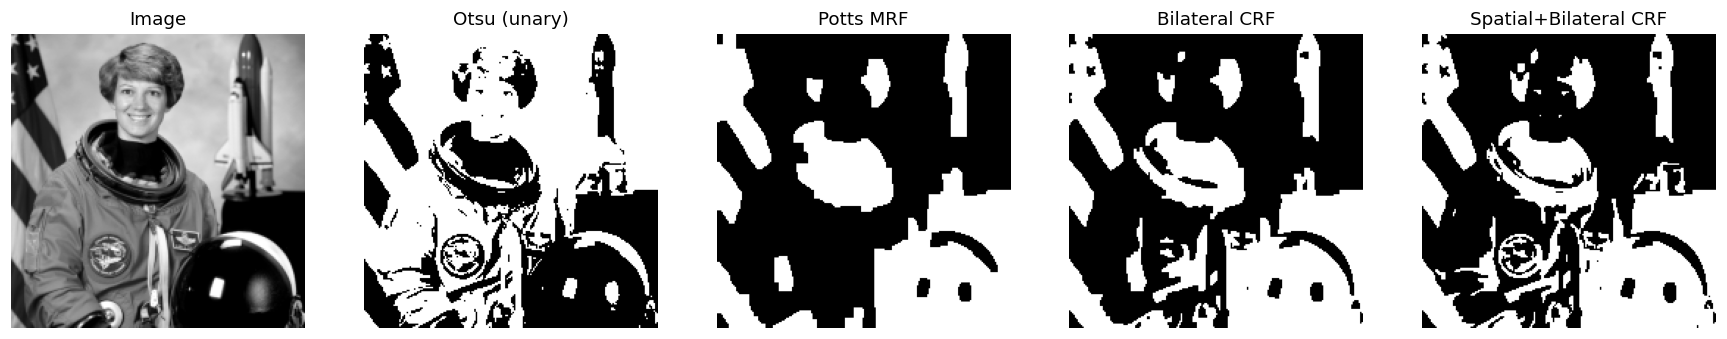

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import maxflow
from skimage import data, color, transform, filters

# Cameraman + Otsu (same setup as the LBP/ICM/SA demos)
gray = color.rgb2gray(transform.resize(data.astronaut(), (200, 200)))
d = (gray > filters.threshold_otsu(gray)).astype(int)   # noisy binary input
H, W = d.shape

# Unary: pay W_DATA if the chosen label disagrees with Otsu's label
W_DATA = 1.0
U_fg = W_DATA * (d != 1)   # cost of labeling pixel as foreground (=1)
U_bg = W_DATA * (d != 0)   # cost of labeling pixel as background (=0)

def segment(pairwise):
    g = maxflow.Graph[float]()
    nodes = g.add_grid_nodes((H, W))
    g.add_grid_tedges(nodes, U_fg, U_bg)
    for i in range(H):
        for j in range(W):
            if j+1 < W: w = pairwise(i,j,i,j+1); g.add_edge(nodes[i,j], nodes[i,j+1], w, w)
            if i+1 < H: w = pairwise(i,j,i+1,j); g.add_edge(nodes[i,j], nodes[i+1,j], w, w)
    g.maxflow()
    return g.get_grid_segments(nodes).astype(int)

# 1. Potts MRF
potts = lambda i1,j1,i2,j2: 2.0

# 2. Bilateral CRF — uses the original grayscale image, not the Otsu mask
bilateral = lambda i1,j1,i2,j2: 2.0 * np.exp(-20 * (gray[i1,j1] - gray[i2,j2])**2)

# 3. Spatial + Bilateral CRF
spat_bilat = lambda i1,j1,i2,j2: 2.0 * np.exp(
    -((i1-i2)**2 + (j1-j2)**2)/2 - (gray[i1,j1] - gray[i2,j2])**2 / 0.02)

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
for a, im, t in zip(ax,
    [gray, d, 1-segment(potts), 1-segment(bilateral), 1-segment(spat_bilat)],
    ['Image', 'Otsu (unary)', 'Potts MRF', 'Bilateral CRF', 'Spatial+Bilateral CRF']):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.show()

Takeaway

- **MRF**: generative. $p(x)$ as a label-only prior. Unary is a likelihood on one tractable channel.
- **CRF**: discriminative. $p(x \mid y)$ directly. Unary and pairwise can use any image features.

*Next Thought: Spacial Distance image features are near constant for 4-connected and 8-connected graphs with a gaussian kernel. How can we utilize the distance between pixels better?


---
# Dense CRFs



# Why a Dense Graph?

**Local graph (4-connected):** information connected to four neighbors. Two pixels far apart have only connection through a chain of intermediate pixels. 

**Concrete failure case:** two patches of the same color separated by a region of different colors. A local CRF can't directly tell them they should share a label — the message has to pass through the dividing region, which fights it the whole way.

**Dense CRF (fully-connected):** every pair of pixels has a pairwise term. Enhances Markov's property by allowing a stronger penalty to be applied to pixels not close to eachother.

$$
E(x \mid y) \;=\; \sum_i V_i(x_i, y) \;+\; \sum_{\substack{(i, j) \\ \textbf{all pairs}}} V_{i,j}(x_i, x_j, y)
$$

Now distant pixels of similar color can directly encourage each other to share a label. The pairwise term doesn't just do local smoothing based on our classification, but can work globally.

*Krähenbühl & Koltun (2011) — the paper that made this practical.*


# Example Where Dense CRF is Useful

Two bright patches of the same color are separated by a dark pixel band. We label **one pixel inside the left patch as foreground**, and the four corners as background. We want both patches.

- **Local CRF (4-connected):** the bilateral pairwise can carry the foreground label across the left patch easily, but to reach the right patch it has to traverse the dark band, where the background classification now propogates.. The label will be switched.
- **Dense pairwise:** every pixel of the right patch has a direct edge to every pixel of the left patch. Pixels with similar color have strong similarity, which can overcome their distance. The right patch finds the left patch directly.


# Previous Optimizers are Not Used

A 4-connected graph on an $N$-pixel image has $\sim 2N$ edges. A fully-connected graph has $\sim N^2 / 2$ edges.

For a 500×500 image:
- 4-connected: $\sim 500{,}000$ edges
- Fully-connected: $\sim 31$ **billion** edges

All previous optimizers discussed cannot handle this.




# Mean-Field Inference

Don't try to find the exact MAP. Instead, **approximate the full posterior**.

Replace the true posterior $P(x \mid y)$ with a **fully-factorized** distribution

$$
Q(x) \;=\; \prod_i Q_i(x_i)
$$

where each $Q_i$ is the marginal probability that pixel $i$ takes each label. Find the $Q$ closest to $P$ by minimizing the KL divergence $\mathrm{KL}(Q \,\|\, P)$.

The optimal $Q_i$ satisfies the fixed-point equation:

$$
Q_i(x_i = k) \;\propto\; \exp\!\Bigl(-\psi_u(k, y_i) \;-\; \sum_{j \ne i}\, \sum_{l} \psi_p(k, l, y_i, y_j)\, Q_j(l)\Bigr)
$$

**Iterate this update for each pixel until convergence.** Each iteration costs the inner sum: $O(N)$ per pixel × $N$ pixels = $O(N^2)$. Still bad.

*Unless the pairwise term has a very specific structure...*


# The Krähenbühl–Koltun Trick (2011)

**The insight:** if the pairwise potential is a **sum of Gaussian kernels** in some feature space, the inner sum in the mean-field update becomes a **Gaussian convolution** of $Q$.

$$
\sum_{j \ne i} k(\mathbf{f}_i, \mathbf{f}_j)\, Q_j(l) \;=\; \bigl[\,k \ast Q_l\,\bigr](i)
$$

Gaussian filtering is $O(N)$ via separability (or the permutohedral lattice for high-D feature spaces). So:

$$
\boxed{\text{Mean-field on a fully-connected CRF is } O(N) \text{ per iteration.}}
$$

**Same cost as the local case.** The graph went from $N$ edges to $N^2$ edges, but the inference still runs in linear time.

**Two kernels** in the original paper:

- **Appearance kernel:** $k_\text{app}(\mathbf{f}_i, \mathbf{f}_j) = \exp(-\tfrac{\|p_i - p_j\|^2}{2\sigma_\alpha^2} - \tfrac{\|I_i - I_j\|^2}{2\sigma_\beta^2})$ — bilateral in (position, color)
- **Smoothness kernel:** $k_\text{smooth}(\mathbf{f}_i, \mathbf{f}_j) = \exp(-\tfrac{\|p_i - p_j\|^2}{2\sigma_\gamma^2})$ — pure spatial

*Result on Pascal VOC: previous best (MCMC) took 36 hours per image. Krähenbühl–Koltun does it in 0.2 seconds with comparable or better accuracy.*


# The Dense CRF Energy

$$
E(x \mid y) \;=\; \sum_i V_i(x_i, y) \;+\; \sum_{(i,j) \text{ all pairs}} V_{i,j}(x_i, x_j, y)
$$

with the pairwise term restricted to a sum of Gaussian kernels:

$$
V_{i,j}(x_i, x_j, y) \;=\; \mu(x_i, x_j) \sum_{m=1}^{M} w_m\, k_m(\mathbf{f}_i, \mathbf{f}_j)
$$

- $\mu(x_i, x_j)$ — label compatibility (usually Potts: $\mathbf{1}[x_i \ne x_j]$)
- $k_m$ — the $m$-th Gaussian kernel
- $\mathbf{f}_i$ — feature vector at pixel $i$ (e.g., position + color)
- $w_m$ — kernel weight



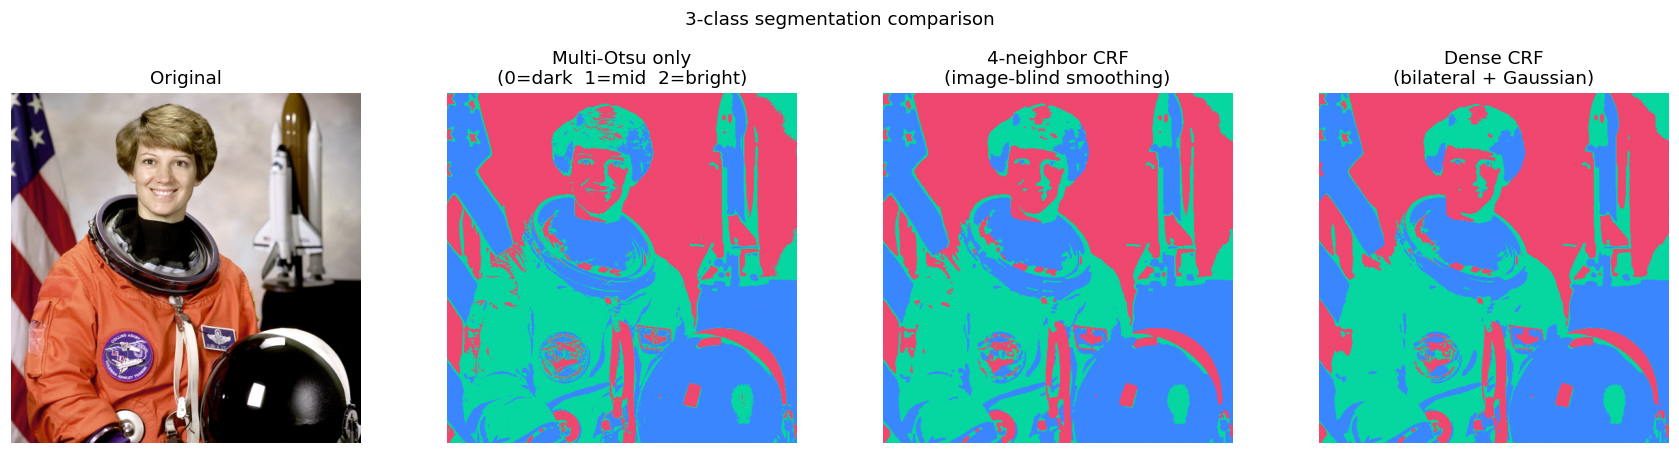

In [8]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import data
from skimage.color import rgb2gray
from skimage.filters import threshold_multiotsu

# ── helpers ───────────────────────────────────────────────────────────────────
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

def joint_bilateral(q, guide, sigma_spatial=12.0, sigma_intensity=0.15, radius=8):
    if guide.ndim == 2:
        guide = guide[..., None]
    out = np.zeros_like(q)
    weights = np.zeros_like(q)
    yy, xx = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_w = np.exp(-(yy**2 + xx**2) / (2 * sigma_spatial**2))
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            sw = spatial_w[dy + radius, dx + radius]
            if sw < 1e-4:
                continue
            sq = np.roll(q,     shift=(dy, dx), axis=(0, 1))
            sg = np.roll(guide, shift=(dy, dx), axis=(0, 1))
            iw = np.exp(-np.sum((guide - sg)**2, axis=-1) / (2 * sigma_intensity**2))
            w  = sw * iw
            out     += w * sq
            weights += w
    return out / np.maximum(weights, 1e-10)

def crf_meanfield_4neighbor(unary, n_iters=10, w_smooth=100.0):
    """
    4-neighbor grid CRF — pure Potts smoothness, no image data in pairwise term.
    High w_smooth + more iterations to make the image-blind smoothing visible.
    """
    H, W, K = unary.shape
    Q = softmax(-unary, axis=-1)
    for _ in range(n_iters):
        msg = np.zeros_like(Q)
        for k in range(K):
            qk = Q[..., k]
            neighbor_sum = (
                np.roll(qk,  1, axis=0) +   # up
                np.roll(qk, -1, axis=0) +   # down
                np.roll(qk,  1, axis=1) +   # left
                np.roll(qk, -1, axis=1)     # right
            )
            msg[..., k] = w_smooth * neighbor_sum
        compat = msg.sum(axis=-1, keepdims=True) - msg  # Potts compatibility
        Q = softmax(-unary - compat, axis=-1)
    return Q

def crf_meanfield_dense(guide, unary, n_iters=5,
                        sigma_alpha=12.0, sigma_intensity=0.15, sigma_gamma=1.5,
                        w_app=20.0, w_smooth=20.0):
    """
    Dense CRF — bilateral (appearance) kernel + Gaussian (smoothness) kernel.
    Pairwise term depends on the image: smoothing respects colour edges.
    """
    H, W, K = unary.shape
    g = guide.astype(np.float32)
    if g.max() > 1.0:
        g = g / 255.0
    Q = softmax(-unary, axis=-1)
    for _ in range(n_iters):
        msg = np.zeros_like(Q)
        for k in range(K):
            qk  = Q[..., k]
            app = joint_bilateral(qk, g, sigma_alpha, sigma_intensity)
            sm  = gaussian_filter(qk, sigma=sigma_gamma, mode='reflect')
            msg[..., k] = w_app * app + w_smooth * sm
        compat = msg.sum(axis=-1, keepdims=True) - msg
        Q = softmax(-unary - compat, axis=-1)
    return Q

# ── data ──────────────────────────────────────────────────────────────────────
rgb  = data.astronaut()
gray = rgb2gray(rgb).astype(np.float32)

thresholds = threshold_multiotsu(gray, classes=3)
d = np.digitize(gray, thresholds).astype(np.uint8)   # 0=dark, 1=mid, 2=bright

W_DATA = 5.0
K = 3
unary = np.zeros((*gray.shape, K), dtype=np.float32)
for k in range(K):
    unary[..., k] = W_DATA * (d != k)

Q_4n    = crf_meanfield_4neighbor(unary, n_iters=10, w_smooth=80.0)
Q_dense = crf_meanfield_dense(rgb, unary, n_iters=5)

# ── plot ──────────────────────────────────────────────────────────────────────
cmap3 = matplotlib.colors.ListedColormap(['#3a86ff', '#06d6a0', '#ef476f'])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(rgb)
axes[0].set_title("Original"); axes[0].axis("off")

axes[1].imshow(d, cmap=cmap3, vmin=0, vmax=2)
axes[1].set_title("Multi-Otsu only\n(0=dark  1=mid  2=bright)"); axes[1].axis("off")

axes[2].imshow(Q_4n.argmax(axis=-1), cmap=cmap3, vmin=0, vmax=2)
axes[2].set_title("4-neighbor CRF\n(image-blind smoothing)"); axes[2].axis("off")

axes[3].imshow(Q_dense.argmax(axis=-1), cmap=cmap3, vmin=0, vmax=2)
axes[3].set_title("Dense CRF\n(bilateral + Gaussian)"); axes[3].axis("off")

plt.suptitle("3-class segmentation comparison", y=1.02)
plt.tight_layout()
plt.show()

# What Dense CRF Doesn't Solve


- **Hyperparameters in prior term/unary term.** $\sigma_\alpha, \sigma_\beta, \sigma_\gamma, w_\text{app}, w_\text{smooth}$ etc are all situation specific.
- **Color similarity is fragile.** Simpler implementations of the prior term cannot handle more complex tasks from deeper image features.
- **Overkill for Some Applications** Relatively computationally expensive, is not worth without significant return.
- **Boundaries from a fixed prior.** The shape of the pairwise kernel is fixed, even though it can capture image features, cannot adapt across different types of images.



## Research Paper using Dense CRF

**Aksoy, Xin, Rupert & Bowman (2025), "Human perception-inspired grain segmentation refinement using conditional random fields," *Materials Characterization* 230, 115694. University of California, Irvine.**

### Goal
The paper addresses the problem that CNNs produce fragmented segmentation masks when detecting grain boundaries in electron microscope images of polycrystalline materials, because the boundaries are only a few pixels wide and easy to break. The authors propose a CRF-based post-processing framework that uses Gestalt perceptual grouping principles (proximity, similarity, closure, continuity, good figure) to reconnect broken boundary segments without retraining the CNN. 

### What the dense CRF was used for
The **segment-based higher-order CRF** works over complete, broken, and completion segments using unary, pairwise, and higher-order Gibbs energy terms. The pairwise term enforces completion and extension constraints, and the higher-order term remembers the geometric features of the grain. 

### Energy function (pixel-level DenseCRF)
The pixel-level DenseCRF uses the standard K&K (2011) pairwise energy — a Potts compatibility function with two Gaussian kernels:

$$\psi_p(y_{p_i}, y_{p_j}) = \mu(y_{p_i}, y_{p_j}) \sum_{m=1}^{K} \left[ \omega^m_p k^m_p(f_i, f_j) \right]$$

where $\mu(y_{p_i}, y_{p_j}) = 1$ if pixels differ in label and 0 otherwise (Potts — penalise any disagreement uniformly), and the two kernels are:

$$k^{(1)}_p = \exp\left\{ -\frac{|p_i - p_j|^2}{2\theta_a^2} - \frac{|I_i - I_j|^2}{2\theta_b^2} \right\} \quad \text{(bilateral)}$$

$$k^{(2)}_p = \exp\left\{ -\frac{|p_i - p_j|^2}{2\theta_c^2} \right\} \quad \text{(smoothness)}$$


## Results from Paper

All improvements compare the segmentation mask before and after CRF post-processing against the fragmented segmentation ground truth (FSGT).

![CRF graphical model](Paper_Output1.png)


### Boundary reconstruction
The most physically meaningful result: the CRF reconnected enough broken boundaries that the number of correctly identified grains jumped from 1206 to 1520 on the validation set (+20.7%), nearly matching the ground truth of 1518. This was the point of using Dense CRFs.

### Grain alignment (paper's custom metric)
Measures the average area difference between predicted grains and their closest ground truth counterpart — a large value means grains are being incorrectly merged due to broken boundaries. The CRF reduced this error by **50.6%** on the validation set (4062.7 → 2007.7) by reconnecting broken boundaries and correctly splitting merged grains.


# Synthesis

**One energy formula, many ways to interpret it.**

$$
E(x, y) \;=\; \sum_i D_i(x_i) \;+\; \sum_{(i,j)} V_{i,j}(x_i, x_j, y)
$$

- **where it comes from:** MAP inference $\arg\max_x p(x \mid y)$ becomes energy minimization by taking negative logs. The unary comes from the likelihood; the pairwise from a Markov prior via Hammersley-Clifford.
- **What optimizer Should be Used** ICM (greedy), graph cuts (exact for binary submodular), loopy BP (arbitrary pairwise). Same energy, different optimizers, different specialties.
- **Introducing CRF** CRF replaces $p(x)$ with $p(x \mid y)$. The bilateral pairwise term we'd been using is *already* a CRF.
- **Dense CRF** every pair of pixels connected. Mean-field with Gaussian-kernel pairwise gives $O(N)$ inference (Krähenbühl-Koltun 2011) — the trick that put CRFs in every segmentation pipeline.



# References

**Foundational**

- Szeliski, R. (2022). *Computer Vision: Algorithms and Applications*, 2nd ed. Ch. 4.3 (Markov random fields). Free PDF at https://szeliski.org/Book/
- Hammersley, J. M., & Clifford, P. (1971). Markov fields on finite graphs and lattices.
- Geman, S., & Geman, D. (1984). Stochastic relaxation, Gibbs distributions, and the Bayesian restoration of images. *PAMI*.

**MRF / CRF**

- Lafferty, J., McCallum, A., & Pereira, F. (2001). Conditional Random Fields: Probabilistic models for segmenting and labeling sequence data. *ICML*.
- Kumar, S., & Hebert, M. (2003). Discriminative Random Fields. *ICCV*.

**Optimizers**

- Besag, J. (1986). On the statistical analysis of dirty pictures. *J. Royal Stat. Soc. B*. (ICM)
- Boykov, Y., & Jolly, M.-P. (2001). Interactive graph cuts for optimal boundary and region segmentation. *ICCV*.
- Boykov, Y., Veksler, O., & Zabih, R. (2001). Fast approximate energy minimization via graph cuts. *PAMI*. (α-expansion)
- Boykov, Y., & Kolmogorov, V. (2004). An experimental comparison of min-cut/max-flow algorithms for energy minimization in vision. *PAMI*.
- Yedidia, J. S., Freeman, W. T., & Weiss, Y. (2001). Generalized belief propagation. *NIPS*.
- Szeliski, R., Zabih, R., et al. (2008). A comparative study of energy minimization methods for Markov random fields with smoothness-based priors. *PAMI*.

**Dense CRF**

- Krähenbühl, P., & Koltun, V. (2011). Efficient inference in fully connected CRFs with Gaussian edge potentials. *NeurIPS*.

**Papers Referenced**

- Aksoy, D., Xin, H. L., Rupert, T. J., & Bowman, W. J. (2025). Human perception-inspired grain segmentation refinement using conditional random fields. Materials Characterization, 230, 115694. https://doi.org/10.1016/j.matchar.2025.115694
- Daoudi, A., & Mahmoudi, S. (2024). Enhancing brain segmentation in MRI through integration of hidden Markov random field model and whale optimization algorithm. Computers, 13(5), 124. https://doi.org/10.3390/computers13050124

AI was used in the development of the slides and reviewing of the material for this presentation.


# Questions?
